# Importaciones

In [ ]:
# Carga de librerías y selección del dispositivo de ejecución.
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
import numpy as np
import networkx as nx

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


c:\repositorios\MULCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


# Descarga de los datos

Los datos utilizados en este notebook se desgargan de kaggle gracias a la libería kagglehub.

In [2]:
# Carga del conjunto de datos y preparación de la serie temporal univariante.
path = kagglehub.dataset_download("chirag19/air-passengers")
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        break

airpassengers = pd.read_csv(csv_path)
data = airpassengers[airpassengers.columns[1]].values.reshape(-1, 1)
print(airpassengers.head(10))

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121
5  1949-06          135
6  1949-07          148
7  1949-08          148
8  1949-09          136
9  1949-10          119


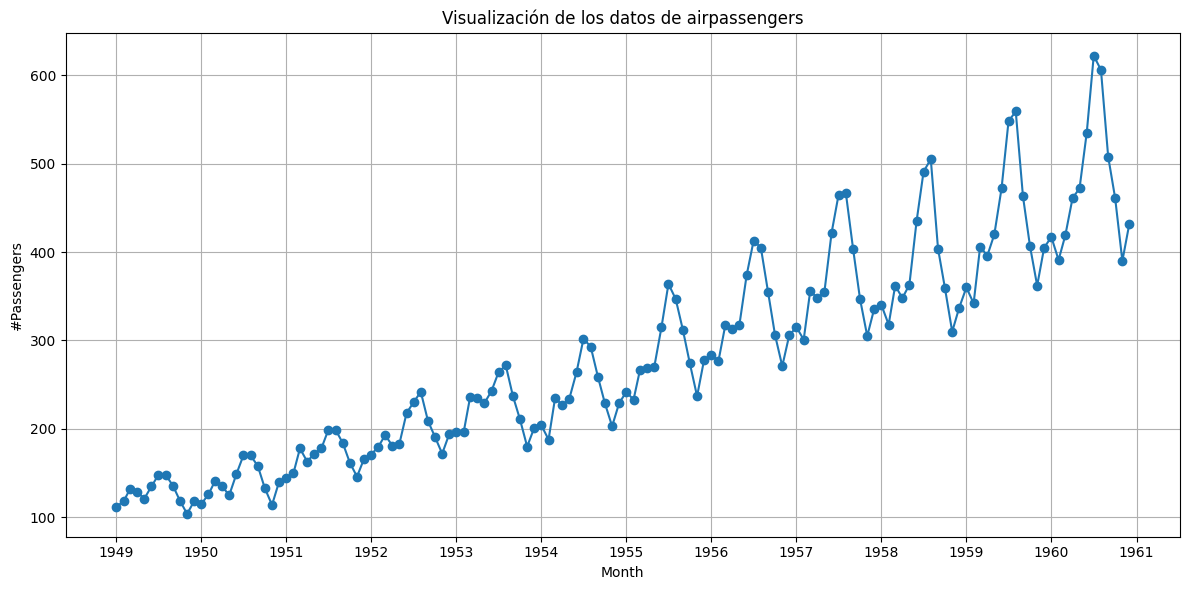

In [3]:
# Visualización inicial de la serie para comprobar tendencia, escala y estacionalidad.
plt.figure(figsize=(12,6))

airpassengers[airpassengers.columns[0]] = pd.to_datetime(airpassengers[airpassengers.columns[0]])

plt.plot(airpassengers[airpassengers.columns[0]], airpassengers[airpassengers.columns[1]], marker='o')
plt.xlabel(airpassengers.columns[0])
plt.ylabel(airpassengers.columns[1])
plt.title('Visualización de los datos de airpassengers')
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

Estos datos no son periódicos, pero sí tienen una estacionalidad que hace que los picos más altos se den cada 12 datos. Las series temporales utilizadas serán de longitud 12 para aprovechar esto.

In [ ]:
# Definición de ventanas temporales y ufunción para igualar pesos iniciales entre RNN y GNN.
seq_length = 12

def create_sequences(data_seq, seq_length):
    xs, ys = [], []
    for i in range(len(data_seq) - seq_length):
        x = data_seq[i:(i+seq_length)]
        y = data_seq[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

def load_gnn_aligned_from_rnn_state_dict(gnn_model: nn.Module, rnn_state_dict: dict) -> None:
    """Copia desde un state_dict del RNN (p.ej. justo antes del entrenamiento) a la GNN alineada."""
    dev = next(gnn_model.parameters()).device
    with torch.no_grad():
        gnn_model.W_x.weight.copy_(rnn_state_dict["rnn.weight_ih_l0"].to(dev))
        gnn_model.conv.lin.weight.copy_(rnn_state_dict["rnn.weight_hh_l0"].to(dev))
        gnn_model.readout.weight.copy_(rnn_state_dict["fc.weight"].to(dev))
        if gnn_model.readout.bias is not None:
            gnn_model.readout.bias.copy_(rnn_state_dict["fc.bias"].to(dev))


### RNN

In [ ]:
# Construcción de secuencias, partición train/test y modelo RNN base.
# Generar datos y dividir en train y test con proporciones 90/10
X, y = create_sequences(data, seq_length)

train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train_tensor = torch.from_numpy(X_train).float().reshape(X_train.shape[0], X_train.shape[1], 1).to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)
X_test_tensor = torch.from_numpy(X_test).float().reshape(X_test.shape[0], X_test.shape[1], 1).to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

# Estructura de una RNN mediante PyTorch
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='relu', bias=False)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, hid = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


### GNN con conexiones extras

In [6]:
# Función para representar cada ventana como grafo lineal con conexiones adicionales.
def create_graph_rnn_structure_plus_extras(sequence, pares, graph = False):
    """
    Crea un grafo para una subserie conectando cada nodo al anterior.
    Los valores de la serie son los atributos de los nodos.
    """

    n = len(sequence)
    edge_index = []

    for i in range(n - 1):
        edge_index.append([i, i + 1])
    edge_index.extend(pares)

    if graph:
        G = nx.DiGraph()
        G.add_edges_from(edge_index)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(8,6))
        nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', arrows=True, node_size=700)
        plt.title("Grafo de las aristas generadas (estructura lineal + conexiones aleatorias, disposición circular)")
        plt.show()

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(sequence, dtype=torch.float).view(-1, 1)

    return Data(x=x, edge_index=edge_index)


Ejemplo de secuencia con conexiones añadidas.

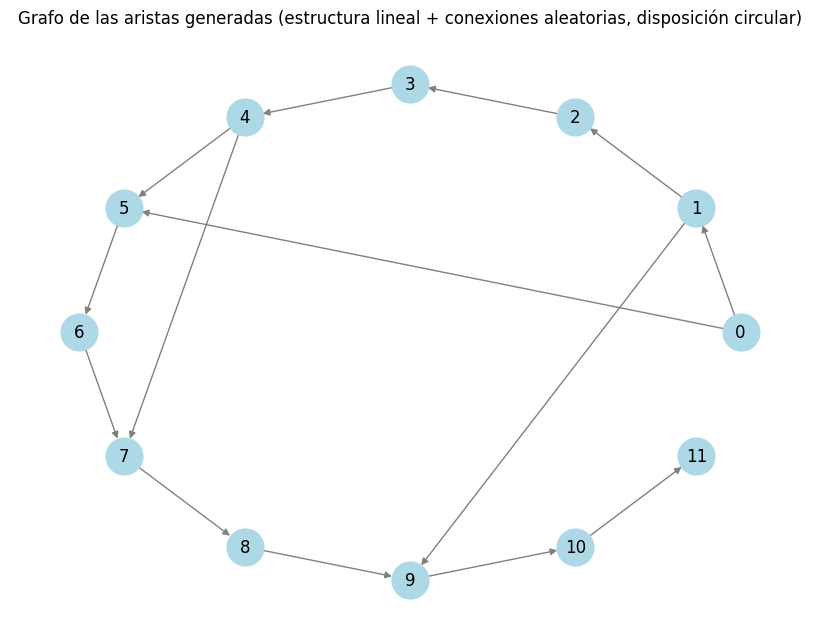

Data(x=[12, 1], edge_index=[2, 14])

In [7]:
# Generación de conexiones extra para los experimentos con variantes de GNN.
np.random.seed(42)

def generate_par(sequence, n):
    rango_num = len(sequence)
    pares = []
    while len(pares) < n:
        par = tuple(np.random.choice(rango_num, 2, replace=False))
        min_par, max_par = min(par), max(par)
        if (
            (min_par, max_par) not in pares and
            abs(max_par - min_par) > 1
        ):
            pares.append((min_par, max_par))

    return pares

pares = generate_par(list(range(12)), 3)
create_graph_rnn_structure_plus_extras(list(range(12)), pares, True)

In [8]:
# Modelo GNN que replica el flujo secuencial de una RNN sobre el grafo.
class GNNasRNN(nn.Module):
    def __init__(self, in_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.W_x = nn.Linear(in_features, hidden_dim, bias = False)
        self.conv = GCNConv(hidden_dim, hidden_dim, add_self_loops=False, normalize=False, bias=False)
        self.readout = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        batch_size = batch.max().item() + 1
        counts = torch.bincount(batch, minlength=batch_size)
        ptr = torch.cat(
            [torch.tensor([0], device=x.device, dtype=torch.long), counts.cumsum(0)]
        )
        num_nodes_per_graph = counts[0].item()

        x_proj = self.W_x(x)
        h = torch.zeros(x.size(0), self.hidden_dim, device=x.device)

        # en cada step solo se actualiza el nodo en posición `step`
        # los demás no sobreescriben su hidden state gracias a la máscara
        for step in range(num_nodes_per_graph):
            h_candidate = F.relu(x_proj + self.conv(h, edge_index))

            node_indices = ptr[:-1] + step
            mask = torch.zeros(x.size(0), 1, device=x.device)
            mask[node_indices] = 1.0
            h = h * (1 - mask) + h_candidate * mask

        last_indices = ptr[1:] - 1
        out = self.readout(h[last_indices])
        return out.squeeze(-1)

# en este caso no se crean los tensores con los datos de entrenamiento y test para no fijar las conexiones aleatorias


### GNN con LRC

In [9]:
# Función para añadir una conexión larga entre el primer y último nodo de la ventana.
def create_graph_rnn_structure_plus_LRC(sequence, graph = False):
    """
    Crea un grafo para una subserie conectando cada nodo al anterior.
    Los valores de la serie son los atributos de los nodos.
    """
    n = len(sequence)
    edge_index = []

    for i in range(n - 1):
        edge_index.append([i, i + 1])
    edge_index.append([0,n-1])

    if graph:
        G = nx.DiGraph()
        G.add_edges_from(edge_index)
        pos = {i: (i, 0) for i in range(n)}
        plt.figure(figsize=(8,6))
        nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', arrows=True, node_size=700)
        plt.title("Grafo de las aristas generadas (estructura RNN sin duplicados)")
        plt.show()

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(sequence, dtype=torch.float).view(-1, 1)

    return Data(x=x, edge_index=edge_index)


In [10]:
# Preparación de grafos con conexión larga fija y sus DataLoader.
# como la conexión LRC no es aleatoria, aquí sí se crean los tensores con los datos de entrenamiento y test
serie_data= data.squeeze()
graphs_lrc = []
labels_lrc = []

for i in range(len(serie_data) - seq_length):
    input_seq = serie_data[i:i+seq_length]
    y = serie_data[i+seq_length]
    graph = create_graph_rnn_structure_plus_LRC(input_seq)
    graph.y = torch.tensor([y], dtype=torch.float)
    graphs_lrc.append(graph)
    labels_lrc.append(torch.tensor([y], dtype=torch.float))

labels_lrc = torch.stack(labels_lrc)
train_size_lrc = int(0.9 * len(graphs_lrc))
graphs_train_lrc, graphs_test_lrc = graphs_lrc[:train_size_lrc], graphs_lrc[train_size_lrc:]
labels_train_lrc, labels_test_lrc = labels_lrc[:train_size_lrc], labels_lrc[train_size_lrc:]

loader_train_lrc = DataLoader(graphs_train_lrc, batch_size=32, shuffle=True)
loader_test_lrc = DataLoader(graphs_test_lrc, batch_size=32, shuffle=False)



### Comparativa

In [ ]:
# Parámetros de entrenamiento
N_RUNS = 100
EPOCHS = 50
BATCH_SIZE = 32
HIDDEN_SIZE = 64
LR = 0.001

# Entrena una RNN desde cero y guarda su estado inicial para alinear la GNN.
def train_rnn_run():
    model_rnn = RNNModel(input_size=1, hidden_size=HIDDEN_SIZE, num_layers=1).to(device)
    rnn_sd_0 = copy.deepcopy(model_rnn.state_dict())
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_rnn.parameters(), lr=LR)
    n = len(X_train_tensor)
    best_test_loss = float('inf')
    best_state = None

    for epoch in range(EPOCHS):
        model_rnn.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            xb, yb = X_train_tensor[idx], y_train_tensor[idx]
            optimizer.zero_grad()
            loss = criterion(model_rnn(xb).squeeze(-1), yb.squeeze(-1))
            loss.backward()
            optimizer.step()

        model_rnn.eval()
        with torch.no_grad():
            test_loss = criterion(model_rnn(X_test_tensor).squeeze(-1), y_test_tensor.squeeze(-1)).item()
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                best_state = copy.deepcopy(model_rnn.state_dict())

    model_rnn.load_state_dict(best_state)
    model_rnn.eval()
    with torch.no_grad():
        pred = model_rnn(X_test_tensor).cpu().numpy()
        actual = y_test_tensor.cpu().numpy()
    return r2_score(actual, pred), best_test_loss, rnn_sd_0

# Entrena la GNN lineal incorporando, si procede, conexiones extra en cada ventana.
def train_gnn_lin_plus_extras_run(rnn_sd_inicial, pares):
    graphs_lin = []
    for i in range(len(serie_data) - seq_length):
        input_seq = serie_data[i : i + seq_length]
        y = serie_data[i + seq_length]
        graph_lin = create_graph_rnn_structure_plus_extras(input_seq, pares)
        graph_lin.y = torch.tensor([y], dtype=torch.float)
        graphs_lin.append(graph_lin)
    train_size = int(0.9 * len(graphs_lin))
    graphs_train_lin, graphs_test_lin = graphs_lin[:train_size], graphs_lin[train_size:]
    loader_train = DataLoader(graphs_train_lin, batch_size=BATCH_SIZE, shuffle=True)
    loader_test = DataLoader(graphs_test_lin, batch_size=BATCH_SIZE, shuffle=False)

    model_lin = GNNasRNN(in_features=1, hidden_dim=HIDDEN_SIZE).to(device)
    load_gnn_aligned_from_rnn_state_dict(model_lin, rnn_sd_inicial)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_lin.parameters(), lr=LR)
    best_test_loss = float('inf')
    best_state = None

    for epoch in range(EPOCHS):
        model_lin.train()
        for batch in loader_train:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model_lin(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.squeeze())
            loss.backward()
            optimizer.step()

        model_lin.eval()
        preds, ys = [], []
        with torch.no_grad():
            for batch in loader_test:
                batch = batch.to(device)
                out = model_lin(batch.x, batch.edge_index, batch.batch)
                preds.extend(out.cpu().numpy())
                ys.extend(batch.y.cpu().numpy())
        preds_np = np.array(preds).squeeze()
        ys_np = np.array(ys).squeeze()
        test_loss = float(np.mean((preds_np - ys_np) ** 2))

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = copy.deepcopy(model_lin.state_dict())

    model_lin.load_state_dict(best_state)
    model_lin.eval()
    preds, ys = [], []
    with torch.no_grad():
        for batch in loader_test:
            batch = batch.to(device)
            out = model_lin(batch.x, batch.edge_index, batch.batch)
            preds.extend(out.cpu().numpy())
            ys.extend(batch.y.cpu().numpy())
    preds_np = np.array(preds).squeeze()
    ys_np = np.array(ys).squeeze()
    return r2_score(ys_np, preds_np), best_test_loss


# Entrena la variante con conexión larga fija entre el inicio y el final de la ventana.
def train_gnn_lrc_run(rnn_sd_inicial):
    model_lrc = GNNasRNN(in_features=1, hidden_dim=HIDDEN_SIZE).to(device)
    load_gnn_aligned_from_rnn_state_dict(model_lrc, rnn_sd_inicial)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_lrc.parameters(), lr=LR)
    best_test_loss = float('inf')
    best_state = None

    for epoch in range(EPOCHS):
        model_lrc.train()
        for batch in loader_train_lrc:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model_lrc(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.squeeze())
            loss.backward()
            optimizer.step()

        model_lrc.eval()
        preds, ys = [], []
        with torch.no_grad():
            for batch in loader_test_lrc:
                batch = batch.to(device)
                out = model_lrc(batch.x, batch.edge_index, batch.batch)
                preds.extend(out.cpu().numpy())
                ys.extend(batch.y.cpu().numpy())
        preds_np = np.array(preds).squeeze()
        ys_np = np.array(ys).squeeze()
        test_loss = float(np.mean((preds_np - ys_np)**2))

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = copy.deepcopy(model_lrc.state_dict())

    model_lrc.load_state_dict(best_state)
    model_lrc.eval()
    preds, ys = [], []
    with torch.no_grad():
        for batch in loader_test_lrc:
            batch = batch.to(device)
            out = model_lrc(batch.x, batch.edge_index, batch.batch)
            preds.extend(out.cpu().numpy())
            ys.extend(batch.y.cpu().numpy())
    preds_np = np.array(preds).squeeze()
    ys_np = np.array(ys).squeeze()
    return r2_score(ys_np, preds_np), best_test_loss


rnn_r2, rnn_loss = [], []
gnn_lin_r2, gnn_lin_loss = [], []
gnn_lin_plus_rand_r2, gnn_lin_plus_rand_loss = [], []
gnn_lin_plus_one_rand_r2, gnn_lin_plus_one_rand_loss = [], []
gnn_lrc_r2, gnn_lrc_loss = [], []

# fijada semilla para asegurar reproducibilidad
np.random.seed(42)

# Repetición los experimentos para estimar medias y variabilidad de cada arquitectura.
for i in range(N_RUNS):
    r2, loss, rnn_sd_0 = train_rnn_run()
    rnn_r2.append(r2)
    rnn_loss.append(loss)

    pares = generate_par(list(range(seq_length)), 0)
    r2, loss = train_gnn_lin_plus_extras_run(rnn_sd_0, pares)
    gnn_lin_r2.append(r2)
    gnn_lin_loss.append(loss)

    pares = generate_par(list(range(seq_length)), 1)
    r2, loss = train_gnn_lin_plus_extras_run(rnn_sd_0, pares)
    gnn_lin_plus_one_rand_r2.append(r2)
    gnn_lin_plus_one_rand_loss.append(loss)

    pares = generate_par(list(range(seq_length)), 3)
    r2, loss = train_gnn_lin_plus_extras_run(rnn_sd_0, pares)
    gnn_lin_plus_rand_r2.append(r2)
    gnn_lin_plus_rand_loss.append(loss)

    r2, loss = train_gnn_lrc_run(rnn_sd_0)
    gnn_lrc_r2.append(r2)
    gnn_lrc_loss.append(loss)

    if (i + 1) % 10 == 0 or i == 0:
        print(f"Run {i+1}/{N_RUNS}")

rnn_r2 = np.array(rnn_r2)
rnn_loss = np.array(rnn_loss)
gnn_lin_r2 = np.array(gnn_lin_r2)
gnn_lin_loss = np.array(gnn_lin_loss)
gnn_lin_plus_one_rand_r2 = np.array(gnn_lin_plus_one_rand_r2)
gnn_lin_plus_one_rand_loss = np.array(gnn_lin_plus_one_rand_loss)
gnn_lin_plus_rand_r2 = np.array(gnn_lin_plus_rand_r2)
gnn_lin_plus_rand_loss = np.array(gnn_lin_plus_rand_loss)
gnn_lrc_r2 = np.array(gnn_lrc_r2)
gnn_lrc_loss = np.array(gnn_lrc_loss)


Run 1/100
Run 10/100
Run 20/100
Run 30/100
Run 40/100
Run 50/100
Run 60/100
Run 70/100
Run 80/100
Run 90/100
Run 100/100


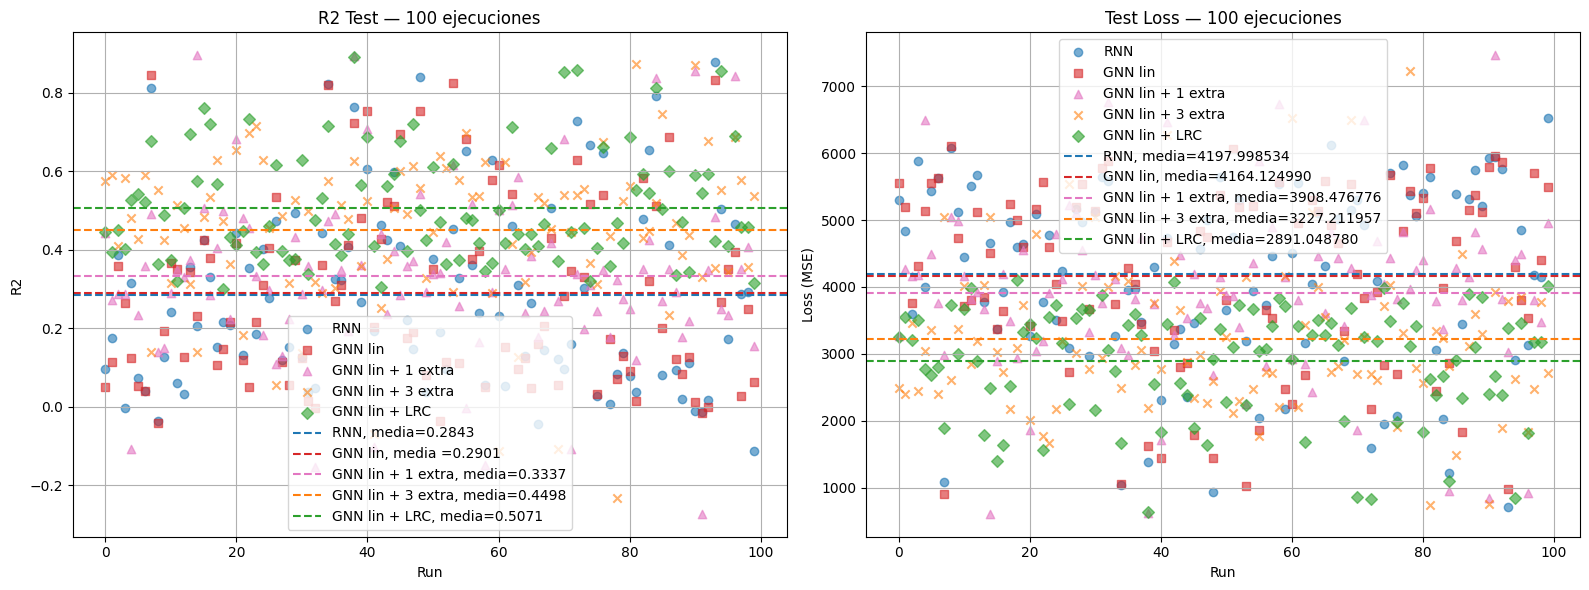


Modelo                           R2 Media       R2 Var   Loss Media       Loss Var
RNN                                0.2843     0.054299  4197.998534 1868212.33151120
GNN lin                            0.2901     0.053436  4164.124990 1838512.93714920
GNN lin + 1 extra                  0.3337     0.044306  3908.476776 1524375.17650527
GNN lin + 3 extra                  0.4498     0.037559  3227.211957 1292257.20358877
GNN lin + LRC                      0.5071     0.019749  2891.048780 679485.31420834


In [14]:
# Resumen gráfico y tabular de R2 y MSE por ejecución.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(range(N_RUNS), rnn_r2, label='RNN', alpha=0.6, marker='o', color='tab:blue')
axes[0].scatter(range(N_RUNS), gnn_lin_r2, label='GNN lin', alpha=0.6, marker='s', color='tab:red')
axes[0].scatter(range(N_RUNS), gnn_lin_plus_one_rand_r2, label='GNN lin + 1 extra', alpha=0.6, marker='^', color='tab:pink')
axes[0].scatter(range(N_RUNS), gnn_lin_plus_rand_r2, label='GNN lin + 3 extra', alpha=0.6, marker='x', color='tab:orange')
axes[0].scatter(range(N_RUNS), gnn_lrc_r2, label='GNN lin + LRC', alpha=0.6, marker='D', color='tab:green')

axes[0].axhline(rnn_r2.mean(), color='tab:blue', linestyle='--', label=f'RNN, media={rnn_r2.mean():.4f}')
axes[0].axhline(gnn_lin_r2.mean(), color='tab:red', linestyle='--', label=f'GNN lin, media ={gnn_lin_r2.mean():.4f}')
axes[0].axhline(gnn_lin_plus_one_rand_r2.mean(), color='tab:pink', linestyle='--', label=f'GNN lin + 1 extra, media={gnn_lin_plus_one_rand_r2.mean():.4f}')
axes[0].axhline(gnn_lin_plus_rand_r2.mean(), color='tab:orange', linestyle='--', label=f'GNN lin + 3 extra, media={gnn_lin_plus_rand_r2.mean():.4f}')
axes[0].axhline(gnn_lrc_r2.mean(), color='tab:green', linestyle='--', label=f'GNN lin + LRC, media={gnn_lrc_r2.mean():.4f}')

axes[0].set_xlabel('Run')
axes[0].set_ylabel('R2')
axes[0].set_title(f'R2 Test — {N_RUNS} ejecuciones')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(range(N_RUNS), rnn_loss, label='RNN', alpha=0.6, marker='o', color='tab:blue')
axes[1].scatter(range(N_RUNS), gnn_lin_loss, label='GNN lin', alpha=0.6, marker='s', color='tab:red')
axes[1].scatter(range(N_RUNS), gnn_lin_plus_one_rand_loss, label='GNN lin + 1 extra', alpha=0.6, marker='^', color='tab:pink')
axes[1].scatter(range(N_RUNS), gnn_lin_plus_rand_loss, label='GNN lin + 3 extra', alpha=0.6, marker='x', color='tab:orange')
axes[1].scatter(range(N_RUNS), gnn_lrc_loss, label='GNN lin + LRC', alpha=0.6, marker='D', color='tab:green')

axes[1].axhline(rnn_loss.mean(), color='tab:blue', linestyle='--', label=f'RNN, media={rnn_loss.mean():.6f}')
axes[1].axhline(gnn_lin_loss.mean(), color='tab:red', linestyle='--', label=f'GNN lin, media={gnn_lin_loss.mean():.6f}')
axes[1].axhline(gnn_lin_plus_one_rand_loss.mean(), color='tab:pink', linestyle='--', label=f'GNN lin + 1 extra, media={gnn_lin_plus_one_rand_loss.mean():.6f}')
axes[1].axhline(gnn_lin_plus_rand_loss.mean(), color='tab:orange', linestyle='--', label=f'GNN lin + 3 extra, media={gnn_lin_plus_rand_loss.mean():.6f}')
axes[1].axhline(gnn_lrc_loss.mean(), color='tab:green', linestyle='--', label=f'GNN lin + LRC, media={gnn_lrc_loss.mean():.6f}')

axes[1].set_xlabel('Run')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title(f'Test Loss — {N_RUNS} ejecuciones')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"{'Modelo':<20} {'R2 Media':>20} {'R2 Var':>12} {'Loss Media':>12} {'Loss Var':>14}")
print(f"{'='*60}")
print(f"{'RNN':<30} {rnn_r2.mean():>10.4f} {rnn_r2.var():>12.6f} {rnn_loss.mean():>12.6f} {rnn_loss.var():>14.8f}")
print(f"{'GNN lin':<30} {gnn_lin_r2.mean():>10.4f} {gnn_lin_r2.var():>12.6f} {gnn_lin_loss.mean():>12.6f} {gnn_lin_loss.var():>14.8f}")
print(f"{'GNN lin + 1 extra':<30} {gnn_lin_plus_one_rand_r2.mean():>10.4f} {gnn_lin_plus_one_rand_r2.var():>12.6f} {gnn_lin_plus_one_rand_loss.mean():>12.6f} {gnn_lin_plus_one_rand_loss.var():>14.8f}")
print(f"{'GNN lin + 3 extra':<30} {gnn_lin_plus_rand_r2.mean():>10.4f} {gnn_lin_plus_rand_r2.var():>12.6f} {gnn_lin_plus_rand_loss.mean():>12.6f} {gnn_lin_plus_rand_loss.var():>14.8f}")
print(f"{'GNN lin + LRC':<30} {gnn_lrc_r2.mean():>10.4f} {gnn_lrc_r2.var():>12.6f} {gnn_lrc_loss.mean():>12.6f} {gnn_lrc_loss.var():>14.8f}")

C:\Users\MagdalenaJáñezVaz\AppData\Local\Temp\ipykernel_24892\1241672502.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(r2_data, vert=True, patch_artist=True, labels=r2_labels)
C:\Users\MagdalenaJáñezVaz\AppData\Local\Temp\ipykernel_24892\1241672502.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(loss_data, vert=True, patch_artist=True, labels=loss_labels)


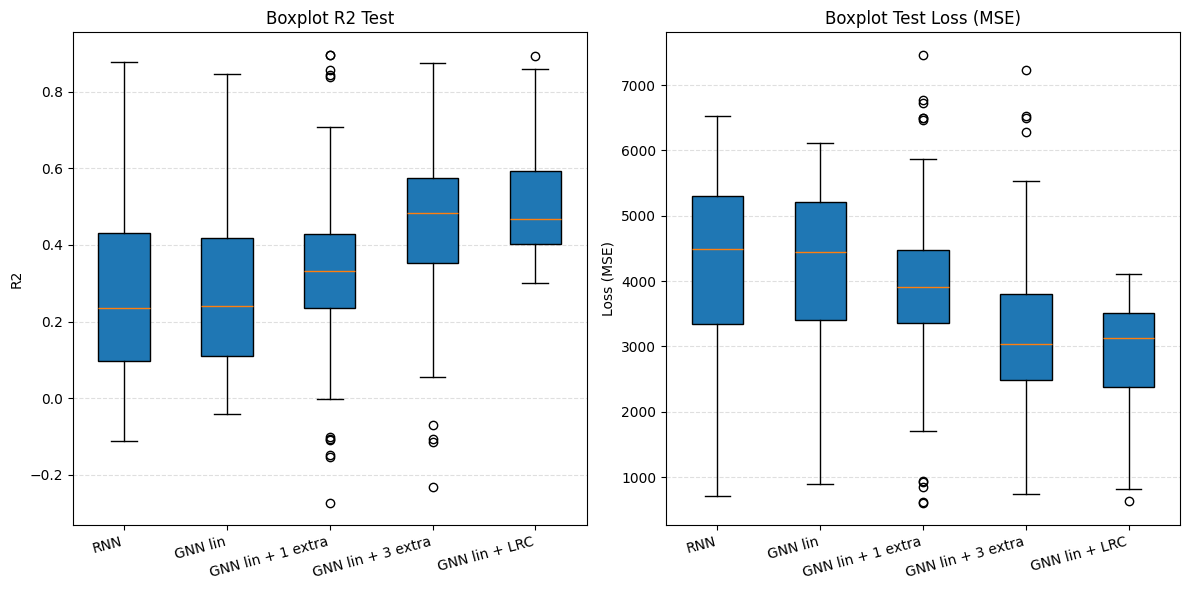

In [13]:
# Boxplots para comparar la distribución de resultados entre modelos.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

r2_data = [
    rnn_r2,
    gnn_lin_r2,
    gnn_lin_plus_one_rand_r2,
    gnn_lin_plus_rand_r2,
    gnn_lrc_r2
]
r2_labels = [
    'RNN',
    'GNN lin',
    'GNN lin + 1 extra',
    'GNN lin + 3 extra',
    'GNN lin + LRC'
]

loss_data = [
    rnn_loss,
    gnn_lin_loss,
    gnn_lin_plus_one_rand_loss,
    gnn_lin_plus_rand_loss,
    gnn_lrc_loss
]
loss_labels = r2_labels

axes[0].boxplot(r2_data, vert=True, patch_artist=True, labels=r2_labels)
axes[0].set_title('Boxplot R2 Test')
axes[0].set_ylabel('R2')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=15)

axes[1].boxplot(loss_data, vert=True, patch_artist=True, labels=loss_labels)
axes[1].set_title('Boxplot Test Loss (MSE)')
axes[1].set_ylabel('Loss (MSE)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)
axes[1].tick_params(axis='x', rotation=15)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.show()